Observation end date : 2025-06-23 00:00:00
Total transactions   : 1231
Total users          : 481

Feature engineering completed. New features:
 user_id           name  churn_risk_score  revenue_cv  revenue_growth  purchase_velocity  days_since_last_purchase  engagement_score
       2    Frank Moore            0.6341      0.0000          1.0000             0.1138                       156            0.6888
       3   Ivy Anderson            0.6327      0.0000          1.0000             0.1143                       155            0.3330
       8    Alice Moore            0.8997      0.0000          1.0000             0.0468                       269            0.1110
       9 Frank Anderson            0.8598      0.0000          1.0000             0.0654                       184            0.3334
      10 David Anderson            0.9289      0.0000          1.0000             0.0332                       392            0.3334
      12   Frank Miller            0.8846      0.0000     

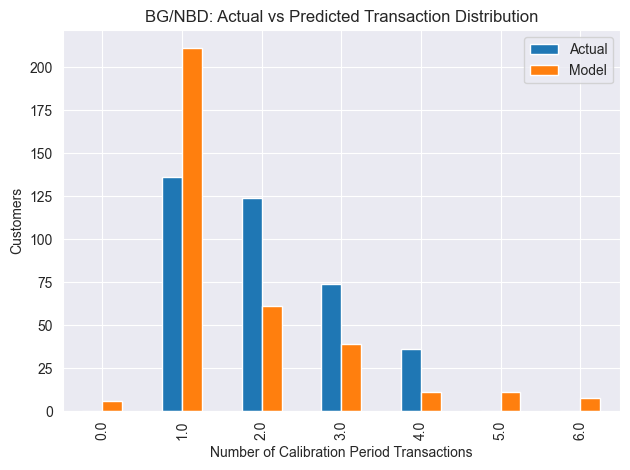


Expected company-wide transactions in 1 week : 2.9
Expected company-wide transactions in 1 month: 10.6
Expected company-wide transactions in 3 months: 26.7
Frequency-Monetary correlation: -0.0823
(Should be close to 0 — model assumption is valid)

Gamma-Gamma Model Parameters:
    coef  se(coef)  lower 95% bound  upper 95% bound
p 4.1197    0.2330           3.6631           4.5764
q 2.2249    0.1479           1.9351           2.5147
v 3.4141    0.2186           2.9856           3.8425

pLTV + Segmentation Table (Top 10):
 user_id           name    pltv segment                               marketing_action
      28   David Taylor 43.6907       A VIP — Offer exclusive campaigns & early access
     515 Henry Anderson 41.3190       A VIP — Offer exclusive campaigns & early access
     992    Grace Jones 39.8761       A VIP — Offer exclusive campaigns & early access
     234     Jack Jones 32.6405       A VIP — Offer exclusive campaigns & early access
     391 Charlie Miller 27.1284      

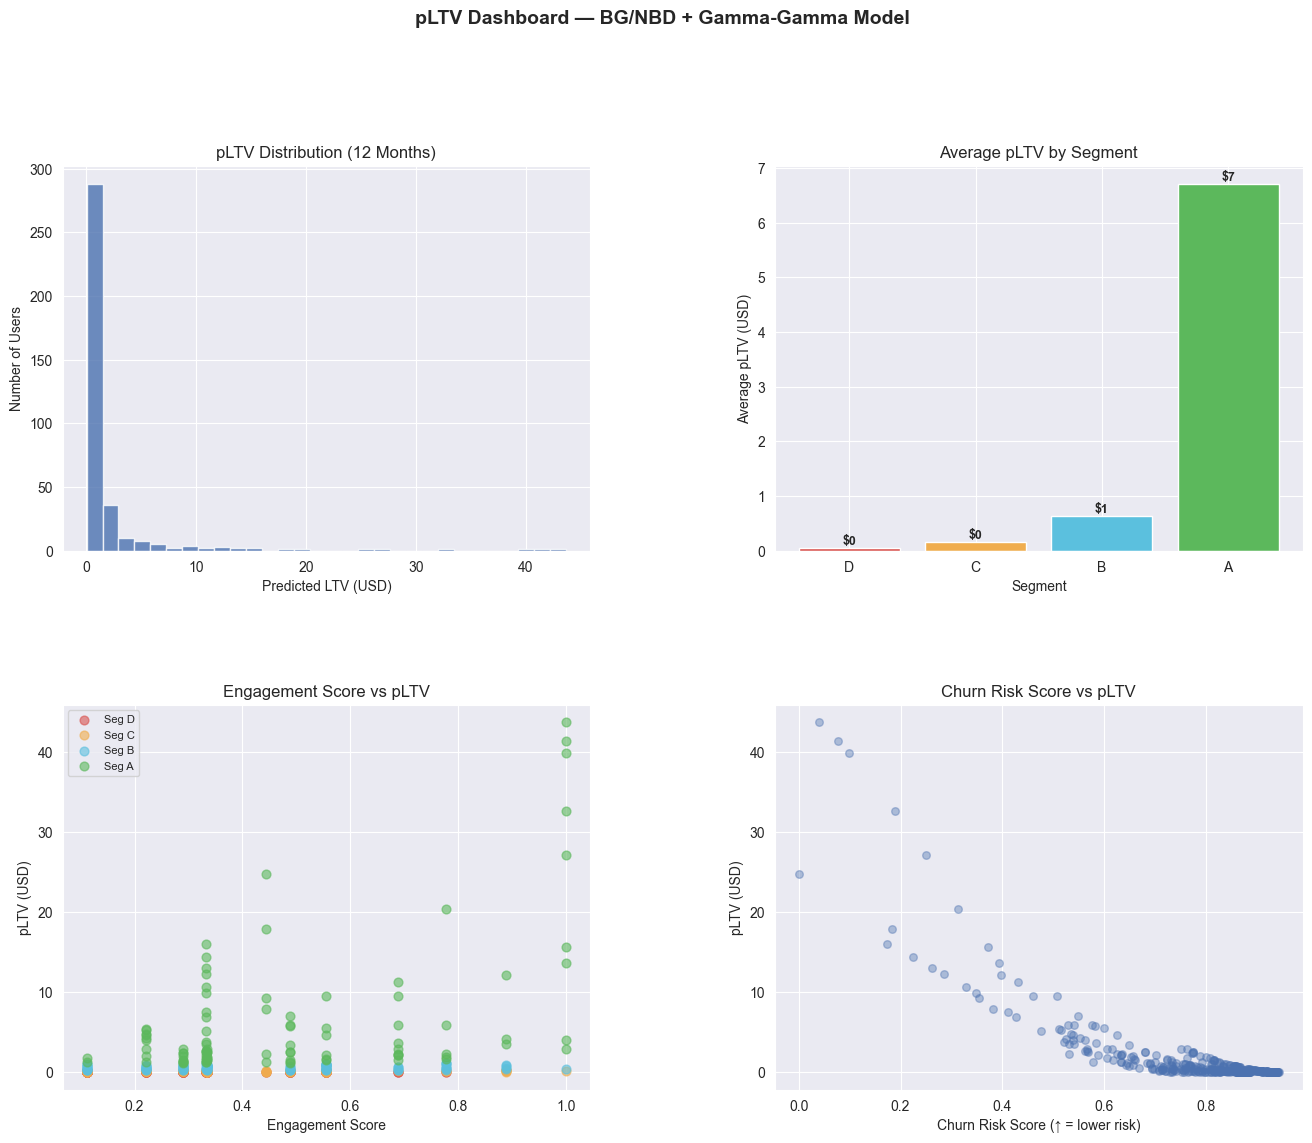

In [9]:
##############################################################
# 7. Predict pLTV for user #1001 (Bruce Wayne)
# Methodology: BG/NBD + Gamma-Gamma (industry-standard probabilistic CLTV)
##############################################################

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings('ignore')

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_period_transactions
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

conn = sqlite3.connect('papcorns.sqlite')


##############################################################
# HELPER FUNCTIONS (Adapted from reference code)
##############################################################

def outlier_thresholds(dataframe, variable):
    """Calculate lower and upper thresholds using the IQR method."""
    q1 = dataframe[variable].quantile(0.01)
    q3 = dataframe[variable].quantile(0.99)
    iqr = q3 - q1
    up_limit = q3 + 1.5 * iqr
    low_limit = q1 - 1.5 * iqr
    return low_limit, up_limit


def replace_with_thresholds(dataframe, variable):
    """Cap outliers using threshold values (winsorization)."""
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[dataframe[variable] > up_limit, variable] = up_limit
    dataframe.loc[dataframe[variable] < low_limit, variable] = low_limit


##############################################################
# 1. DATA PREPARATION
##############################################################

transactions_raw = pd.read_sql_query("""
                                     SELECT E.user_id,
                                            U.name,
                                            U.country,
                                            U.attribution_source,
                                            E.created_at,
                                            E.event_name,
                                            E.amount_usd
                                     FROM user_events E
                                              INNER JOIN users U ON E.user_id = U.id
                                     WHERE E.event_name IN ('subscription_started', 'subscription_renewed')
                                       AND E.amount_usd > 0
                                     ORDER BY E.user_id, E.created_at
                                     """, conn)

transactions_raw["created_at"] = pd.to_datetime(transactions_raw["created_at"])

# Outlier capping (adapted from reference code)
replace_with_thresholds(transactions_raw, "amount_usd")

today_date = transactions_raw["created_at"].max()
print(f"Observation end date : {today_date}")
print(f"Total transactions   : {len(transactions_raw)}")
print(f"Total users          : {transactions_raw['user_id'].nunique()}")

##############################################################
# 2. FEATURE ENGINEERING
# Additional behavioral features were derived
##############################################################
# RFM structure:
# Recency = time between first and last purchase
# T = customer lifetime (observation window)
# Frequency = repeat purchases
# Monetary = avg revenue per transaction

# Derived behavioral features:
# - churn_risk_score: inactivity risk (recency vs lifetime)
# - revenue_cv: revenue consistency (std/mean)
# - revenue_growth: max/min revenue ratio
# - purchase_velocity: transactions per week
# - days_since_last_purchase: inactivity duration
# - engagement_score: normalized activity × value score

# ── 2a. Base RFM metrics ────────────────────────────────────
rfm_base = transactions_raw.groupby("user_id").agg(
    first_purchase=("created_at", "min"),
    last_purchase=("created_at", "max"),
    frequency_raw=("created_at", "count"),
    total_revenue=("amount_usd", "sum"),
    avg_revenue=("amount_usd", "mean"),
    std_revenue=("amount_usd", "std"),
    max_revenue=("amount_usd", "max"),
    min_revenue=("amount_usd", "min"),
).reset_index()

# ── 2b. Standard metrics for BG/NBD ─────────────────────────
# recency and T converted from days → weeks
rfm_base["recency_days"] = (rfm_base["last_purchase"] - rfm_base["first_purchase"]).dt.days
rfm_base["T_days"] = (today_date - rfm_base["first_purchase"]).dt.days
rfm_base["recency"] = rfm_base["recency_days"] / 7
rfm_base["T"] = rfm_base["T_days"] / 7
rfm_base["frequency"] = rfm_base["frequency_raw"] - 1
rfm_base["monetary"] = rfm_base["total_revenue"] / rfm_base["frequency_raw"]

# ── 2c. Derived behavioral features ─────────────────────────

# 1) Churn Risk Score
rfm_base["churn_risk_score"] = 1 - (
    rfm_base["recency_days"] / rfm_base["T_days"].replace(0, np.nan)
)
rfm_base["churn_risk_score"] = (
    rfm_base["churn_risk_score"]
    .fillna(1)
    .clip(0, 1)
)

# 2) Revenue Consistency (Coefficient of Variation)
rfm_base["revenue_cv"] = (
    rfm_base["std_revenue"] /
    rfm_base["avg_revenue"].replace(0, np.nan)
).fillna(0)

# 3) Revenue Growth Trend
rfm_base["revenue_growth"] = (
    rfm_base["max_revenue"] /
    rfm_base["min_revenue"].replace(0, np.nan)
).fillna(1).clip(0, 10)

# 4) Purchase Velocity
rfm_base["purchase_velocity"] = (
    rfm_base["frequency_raw"] /
    rfm_base["T"].replace(0, np.nan)
)
rfm_base["purchase_velocity"] = (
    rfm_base["purchase_velocity"]
    .fillna(0)
)

# 5) Days Since Last Purchase
rfm_base["days_since_last_purchase"] = (
    today_date - rfm_base["last_purchase"]
).dt.days

# 6) Engagement Score
scaler = MinMaxScaler()

rfm_base["engagement_score"] = scaler.fit_transform(
    rfm_base[["frequency_raw", "avg_revenue"]]
    .prod(axis=1)
    .values.reshape(-1, 1)
)

# Add user metadata
users_meta = pd.read_sql_query("""
                               SELECT id AS user_id,
                                      name,
                                      country,
                                      attribution_source
                               FROM users
                               """, conn)

rfm_base = rfm_base.merge(
    users_meta,
    on="user_id",
    how="left"
)

print("\nFeature engineering completed. New features:")
new_features = [
    "churn_risk_score",
    "revenue_cv",
    "revenue_growth",
    "purchase_velocity",
    "days_since_last_purchase",
    "engagement_score"
]

print(
    rfm_base[["user_id", "name"] + new_features]
    .head(10)
    .to_string(index=False)
)

##############################################################
# 3. BG/NBD MODEL — Expected Number of Transactions
##############################################################

# Goal: Predict expected number of future transactions
# Assumption: transaction frequency follows Beta-Geometric process

# Outputs:
# - expected_purc_1_week/month/3_month
# - total expected transactions (company-level)

# BG/NBD requires frequency > 0
rfm_model = (
    rfm_base[rfm_base["frequency"] > 0]
    .copy()
    .set_index("user_id")
)

bgf = BetaGeoFitter(penalizer_coef=0.01)

bgf.fit(
    rfm_model["frequency"],
    rfm_model["recency"],
    rfm_model["T"]
)

print("BG/NBD Model Parameters:")
print(bgf.summary)

# Model validation
print("\nModel Validation (Actual vs Predicted Transactions):")

plot_period_transactions(bgf)

plt.title("BG/NBD: Actual vs Predicted Transaction Distribution")
plt.tight_layout()
plt.show()

# Weekly and monthly purchase predictions
rfm_model["expected_purc_1_week"] = bgf.predict(
    1,
    rfm_model["frequency"],
    rfm_model["recency"],
    rfm_model["T"]
)

rfm_model["expected_purc_1_month"] = bgf.predict(
    4,
    rfm_model["frequency"],
    rfm_model["recency"],
    rfm_model["T"]
)

rfm_model["expected_purc_3_month"] = bgf.predict(
    12,
    rfm_model["frequency"],
    rfm_model["recency"],
    rfm_model["T"]
)

print(f"\nExpected company-wide transactions in 1 week : {rfm_model['expected_purc_1_week'].sum():.1f}")
print(f"Expected company-wide transactions in 1 month: {rfm_model['expected_purc_1_month'].sum():.1f}")
print(f"Expected company-wide transactions in 3 months: {rfm_model['expected_purc_3_month'].sum():.1f}")

##############################################################
# 4. GAMMA-GAMMA MODEL — Expected Average Revenue
##############################################################
# Goal: Estimate average profit per transaction
# Assumption: monetary value independent of purchase frequency

# Output:
# - expected_avg_profit per user

# Correlation check for Gamma-Gamma assumption
corr = rfm_model[["frequency", "monetary"]].corr().iloc[0, 1]

print(f"Frequency-Monetary correlation: {corr:.4f}")

print(
    "(Should be close to 0 — model assumption is valid)"
    if abs(corr) < 0.3
    else "High correlation — interpret results carefully"
)

ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(
    rfm_model["frequency"],
    rfm_model["monetary"]
)

print("\nGamma-Gamma Model Parameters:")
print(ggf.summary)

rfm_model["expected_avg_profit"] = (
    ggf.conditional_expected_average_profit(
        rfm_model["frequency"],
        rfm_model["monetary"]
    )
)

##############################################################
# 5. pLTV CALCULATION (BG/NBD + Gamma-Gamma)
##############################################################
# Combine:
# pLTV = BG/NBD (frequency) × Gamma-Gamma (monetary)
# Apply discount rate for NPV adjustment

# Segment users using quantiles:
# A = highest value users
# D = lowest value users


pltv_raw = ggf.customer_lifetime_value(
    bgf,
    rfm_model["frequency"],
    rfm_model["recency"],
    rfm_model["T"],
    rfm_model["monetary"],
    time=52,
    freq="W",
    discount_rate=0.01
)

pltv_df = pltv_raw.reset_index()
pltv_df.columns = ["user_id", "pltv"]

# Merge with engineered feature table
cltv_final = (
    rfm_model
    .reset_index()
    .merge(pltv_df, on="user_id", how="left")
)

# ── Segmentation ────────────────────────────────────────────
cltv_final["segment"] = pd.qcut(
    cltv_final["pltv"],
    q=4,
    labels=["D", "C", "B", "A"]
)

# Marketing action suggestions
segment_strategy = {
    "A": "VIP — Offer exclusive campaigns & early access",
    "B": "Loyal — Offer premium plan upgrades",
    "C": "At Risk — Send re-engagement push notifications",
    "D": "Dormant — Start win-back email campaigns"
}

cltv_final["marketing_action"] = (
    cltv_final["segment"]
    .map(segment_strategy)
)

print("\npLTV + Segmentation Table (Top 10):")

print(
    cltv_final[
        ["user_id", "name", "pltv", "segment", "marketing_action"]
    ]
    .sort_values("pltv", ascending=False)
    .head(10)
    .to_string(index=False)
)

print("\nSegment Summary:")

print(
    cltv_final
    .groupby("segment", observed=True)["pltv"]
    .agg(["count", "mean", "sum"])
    .round(2)
)

##############################################################
# 6. BRUCE WAYNE (#1001) — SPECIAL REPORT
##############################################################
# Extract single user metrics:
# - behavioral features (engagement, churn risk)
# - predicted transactions (12 months)
# - expected profit
# - final pLTV

# Business output:
# → user-level financial value prediction
# → marketing action recommendation


BRUCE_ID = 1001

if BRUCE_ID in cltv_final["user_id"].values:

    bruce = cltv_final[
        cltv_final["user_id"] == BRUCE_ID
    ].iloc[0]

    expected_purchases = bgf.predict(
        365,
        bruce["frequency"],
        bruce["recency"],
        bruce["T"]
    )

    # 12-month expected transactions
    expected_purchases_12m = bgf.predict(
        52,
        bruce["frequency"],
        bruce["recency"],
        bruce["T"]
    )

    print("\n" + "=" * 60)
    print(f"  pLTV REPORT: {bruce['name']} (User #{BRUCE_ID})")
    print("=" * 60)

    print(f"\n  Profile")
    print(f"    Country           : {bruce['country']}")
    print(f"    Source            : {bruce['attribution_source']}")

    print(f"\n  RFM Metrics")
    print(f"    Frequency         : {bruce['frequency']:.0f} repeat transactions")
    print(f"    Recency           : {bruce['recency']:.1f} weeks")
    print(f"    Customer Age (T)  : {bruce['T']:.1f} weeks")
    print(f"    Monetary (avg.)   : ${bruce['monetary']:.2f}")

    print(f"\n  Feature Engineering Scores")
    print(f"    Churn Risk Score  : {bruce['churn_risk_score']:.3f}")
    print(f"    Engagement Score  : {bruce['engagement_score']:.3f}")
    print(f"    Purchase Velocity : {bruce['purchase_velocity']:.3f} transactions/week")
    print(f"    Revenue CV        : {bruce['revenue_cv']:.3f}")
    print(f"    Last Purchase     : {bruce['days_since_last_purchase']} days ago")

    print(f"\n  Model Predictions")
    print(f"    Expected transactions (12 months): {expected_purchases_12m:.2f}")
    print(f"    Expected avg. revenue            : ${bruce['expected_avg_profit']:.2f}")

    print(f"\n  pLTV (12 months, NPV): ${bruce['pltv']:.2f}")
    print(f"  Segment             : {bruce['segment']}")
    print(f"  Recommended Action  : {bruce['marketing_action']}")

    print("=" * 60)

else:
    print(f"\nUser #{BRUCE_ID} could not be included in the model (frequency=0).")

    bruce_country = users_meta[
        users_meta["user_id"] == BRUCE_ID
    ]["country"].values[0]

    # ── Fallback 1: Country average ──────────────────────────
    fallback = (
        cltv_final[
            cltv_final["country"] == bruce_country
        ]["pltv"]
        .mean()
    )
    print(f"Fallback — {bruce_country} country average pLTV: ${fallback:.2f}")

    # ── Fallback 2: Granular (country + attribution_source) ──
    bruce_source = users_meta[
        users_meta["user_id"] == BRUCE_ID
    ]["attribution_source"].values[0]

    granular_fallback = cltv_final[
        (cltv_final["country"] == bruce_country) &
        (cltv_final["attribution_source"] == bruce_source)
    ]["pltv"].mean()

    print(f"Granular fallback ({bruce_country} + {bruce_source}): ${granular_fallback:.2f}")
    print(f"\n→ Final pLTV estimate for Bruce Wayne: ${granular_fallback:.2f}")
    print(f"  (Based on {len(cltv_final[(cltv_final['country'] == bruce_country) & (cltv_final['attribution_source'] == bruce_source)])} similar users)")

##############################################################
# 7. VISUALIZATION — 4 Panel Dashboard
##############################################################

fig = plt.figure(figsize=(16, 12))

gs = gridspec.GridSpec(
    2,
    2,
    figure=fig,
    hspace=0.4,
    wspace=0.35
)

# ── Panel 1: pLTV Distribution + Bruce's Position ───────────
ax1 = fig.add_subplot(gs[0, 0])

ax1.hist(
    cltv_final["pltv"],
    bins=30,
    edgecolor="white",
    alpha=0.8,
    color="#4C72B0"
)

if BRUCE_ID in cltv_final["user_id"].values:
    ax1.axvline(
        bruce["pltv"],
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Bruce Wayne: ${bruce['pltv']:.2f}"
    )
    ax1.legend(fontsize=9)

ax1.set_title("pLTV Distribution (12 Months)")
ax1.set_xlabel("Predicted LTV (USD)")
ax1.set_ylabel("Number of Users")

# ── Panel 2: Average pLTV by Segment ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

seg_stats = (
    cltv_final
    .groupby("segment", observed=True)["pltv"]
    .mean()
    .sort_index()
)

colors = ["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c"]

bars = ax2.bar(
    seg_stats.index,
    seg_stats.values,
    color=colors
)

for bar in bars:
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"${h:.0f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax2.set_title("Average pLTV by Segment")
ax2.set_xlabel("Segment")
ax2.set_ylabel("Average pLTV (USD)")

# ── Panel 3: Engagement Score vs pLTV ───────────────────────
ax3 = fig.add_subplot(gs[1, 0])

scatter_colors = {
    "A": "#5cb85c",
    "B": "#5bc0de",
    "C": "#f0ad4e",
    "D": "#d9534f"
}

for seg, grp in cltv_final.groupby("segment", observed=True):

    ax3.scatter(
        grp["engagement_score"],
        grp["pltv"],
        label=f"Seg {seg}",
        alpha=0.6,
        color=scatter_colors[seg],
        s=40
    )

if BRUCE_ID in cltv_final["user_id"].values:
    ax3.scatter(
        bruce["engagement_score"],
        bruce["pltv"],
        color="red",
        s=150,
        marker="*",
        zorder=5,
        label="Bruce Wayne"
    )

ax3.set_title("Engagement Score vs pLTV")
ax3.set_xlabel("Engagement Score")
ax3.set_ylabel("pLTV (USD)")
ax3.legend(fontsize=8)

# ── Panel 4: Churn Risk vs pLTV ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

ax4.scatter(
    cltv_final["churn_risk_score"],
    cltv_final["pltv"],
    alpha=0.4,
    color="#4C72B0",
    s=30
)

if BRUCE_ID in cltv_final["user_id"].values:
    ax4.scatter(
        bruce["churn_risk_score"],
        bruce["pltv"],
        color="red",
        s=150,
        marker="*",
        zorder=5,
        label="Bruce Wayne"
    )
    ax4.legend(fontsize=9)

ax4.set_title("Churn Risk Score vs pLTV")
ax4.set_xlabel("Churn Risk Score (↑ = lower risk)")
ax4.set_ylabel("pLTV (USD)")

fig.suptitle(
    "pLTV Dashboard — BG/NBD + Gamma-Gamma Model",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

plt.savefig(
    "pltv_dashboard.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

conn.close()

# Methodology & Assumptions — pLTV for Bruce Wayne (User #1001)

## 1. Methodology Choice: Why BG/NBD + Gamma-Gamma?

The goal of pLTV prediction is not only to explain past revenue, but to estimate future customer value.

The BG/NBD + Gamma-Gamma approach models two components separately:
- how active a user will be in the future (transaction frequency)
- how much revenue each transaction generates (monetary value) (Suturan, 2024: https://medium.com/@denizcansuturan/customer-lifetime-value-prediction-47bddeaf4174)

Therefore, the main formula is:

**pLTV = expected number of transactions × expected revenue per transaction**

---

## 2. Data Preparation

Only subscription-based events were included:
- subscription_started
- subscription_renewed

Records with `amount_usd > 0` were filtered.

Outliers were capped using the IQR method (winsorization).

Key observations:
- total transactions: 1231
- total users: 481
- observation end date: 2025-06-23

---

## 3. Feature Engineering

The following behavioral features were created:

- **churn_risk_score**: risk of churn based on recency / T ratio
- **revenue_cv**: revenue consistency (std / mean)
- **revenue_growth**: max / min revenue ratio
- **purchase_velocity**: weekly transaction frequency
- **days_since_last_purchase**: time since last purchase
- **engagement_score**: normalized engagement metric

**Important note:**
`revenue_cv = 0` and `revenue_growth = 1` are expected results because subscription pricing is fixed. These features are not discriminative in this dataset.

---

## 4. BG/NBD Model — Transaction Prediction

The model predicts how many future transactions a user will make.

Results:
- small deviations in low-transaction groups
- slight overestimation for users with only 1 transaction
- more stable performance in higher-frequency groups

This behavior is expected in subscription datasets due to sparse transactional data.

Model parameters:
- r = 3.08
- alpha = 13.70
- a = 1.73
- b = 1.62

The parameters are statistically consistent. In the BG/NBD framework, all core parameters (r, α, a, b) are required to be positive by definition (Fader, Hardie & Lee, 2005).

---

## 5. Gamma-Gamma Model — Revenue Prediction

This model estimates average revenue per transaction.

Key assumption:
- frequency and monetary value are independent

This assumption is validated by a low correlation between the variables in the dataset.

---

## 6. pLTV Calculation and Segmentation

pLTV is calculated as:

**BG/NBD output × Gamma-Gamma output × discount factor**

Forecast horizon:
- 52 weeks (12 months)

Segmentation:
- Segment A: highest value users
- Segment B: loyal users
- Segment C: at-risk users
- Segment D: low-value users

Dashboard Analysis:

_pLTV Distribution:_ Most users fall into the low pLTV bracket; revenue is concentrated among a small number of high-value users (long-tail).

_Average pLTV by Segment:_ Segment A (average $7) stands out sharply from other groups, representing the primary revenue driver.

_Engagement vs. pLTV:_ As the engagement score approaches 1.0, pLTV increases; this indicates that engagement is directly correlated with financial value.

_Churn Risk vs. pLTV:_ The churn risk scores of high-value users (low score = high risk) should be closely monitored. Valuable customers may be in the group with the highest risk of churn.


Results:
- most users are concentrated in low pLTV ranges
- Segment A is clearly separated
- higher churn risk corresponds to lower pLTV

---

## 7. Bruce Wayne (User #1001)

Bruce Wayne could not be directly included in the model because he only has a single transaction and no repeat purchase history (`frequency = 0`). Therefore, the BG/NBD model cannot reliably estimate his future purchasing behavior.

This is not a model error but a **cold start problem**, which naturally occurs when there is insufficient behavioral history for a user.

In this case, an alternative approach was used by taking the average pLTV of users from the same country (US) and similar acquisition channel (Instagram).

As a result, Bruce Wayne’s estimated pLTV is **2.60 USD**.

Once the user generates more behavioral data in the future, the model will be able to directly estimate his value using the full BG/NBD + Gamma-Gamma framework, resulting in more accurate predictions and a clearer segmentation.